# 3.1 Linear Regression

**Regression** problems come up whenever we want to predict a numerical value — the
price of a home, a patient's length of stay, retail demand. As a running example, we
estimate a house's **price** (in dollars) from its **area** (square feet) and **age**
(years).

A few terms recur throughout the book: the dataset used for fitting is the **training
dataset** (or *training set*); each row is an **example** (*data point*, *instance*,
*sample*); the quantity we predict (price) is the **label** (or *target*); and the
variables we predict it from (area, age) are the **features** (or *covariates*).

In [1]:
%matplotlib inline
import math                   # sqrt, pi for the normal pdf
import time                   # wall-clock timing: loop vs. vectorized addition
import numpy as np            # array math for the pdf function and its plot
import torch                  # tensors for the vectorization demo and the analytic-solution check
from d2l import torch as d2l  # d2l plotting/utility helpers (PyTorch backend)

## 3.1.1 Basics

**Linear regression** is both the simplest and the most widely used regression tool,
dating back to Gauss (1809) and Legendre (1805). It rests on two assumptions: the
conditional mean $E[Y \mid X = \mathbf{x}]$ is (approximately) a weighted sum of the
features — so the target can still deviate from that expectation due to observation
noise — and that noise is well-behaved, following a **Gaussian** distribution
(§3.1.3 makes this precise).

Notation used throughout: $n$ is the number of examples, superscripts index examples
and subscripts index coordinates, so $\mathbf{x}^{(i)}$ is the $i$-th example and
$x_j^{(i)}$ is its $j$-th feature.

### 3.1.1.1 Model

For the house-price example, linearity means the expected price is a weighted sum of
the two features:

$$\text{price} = w_{\text{area}} \cdot \text{area} + w_{\text{age}} \cdot \text{age} + b,$$

where $w_{\text{area}}, w_{\text{age}}$ are **weights** and $b$ is the **bias**
(*offset*, *intercept*) — the prediction when every feature is zero. We keep $b$ even
though no house has exactly zero area, because without it we could only express lines
through the origin. Strictly, this is an **affine transformation**: a linear
transformation (the weighted sum) plus a translation (the bias).

With $d$ features indexed $1, \ldots, d$, the general prediction is

$$\hat{y} = w_1 x_1 + \cdots + w_d x_d + b = \mathbf{w}^\top \mathbf{x} + b,$$

collecting features into $\mathbf{x} \in \mathbb{R}^d$ and weights into
$\mathbf{w} \in \mathbb{R}^d$. Stacking $n$ examples as rows of a **design matrix**
$\mathbf{X} \in \mathbb{R}^{n \times d}$, the whole batch of predictions is one
matrix–vector product,

$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b,$$

with $b$ broadcast across rows. Given a training dataset $(\mathbf{X}, \mathbf{y})$,
the goal is to choose $\mathbf{w}$ and $b$ — the **parameters** — so that a new
example from the same distribution is predicted with the smallest expected error.

### 3.1.1.2 Loss Function

We need a measure of fitness before we can search for good parameters. For
regression, the standard choice is the **squared error**: for example $i$ with
prediction $\hat{y}^{(i)}$ and true label $y^{(i)}$,

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2}\left(\hat{y}^{(i)} - y^{(i)}\right)^2.$$

The $\frac{1}{2}$ is just notational convenience — it cancels when we differentiate.
Because it is quadratic, the loss punishes large errors disproportionately more than
small ones, which helps the model avoid big misses but also makes it sensitive to
outliers. To score a whole dataset we average over all $n$ examples:

$$L(\mathbf{w}, b) = \frac{1}{n}\sum_{i=1}^{n} l^{(i)}(\mathbf{w}, b)
= \frac{1}{n}\sum_{i=1}^{n}\frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2,$$

and training means finding
$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b} L(\mathbf{w}, b)$.

### 3.1.1.3 Analytic Solution

Linear regression is unusually forgiving: it is one of the few models in this book
with a **closed-form** solution. Folding the bias into $\mathbf{w}$ by appending a
column of 1s to $\mathbf{X}$, the objective becomes $\lVert \mathbf{y} -
\mathbf{X}\mathbf{w}\rVert^2$. Since it is convex, setting its gradient to zero,
$\partial_{\mathbf{w}}\lVert \mathbf{y} - \mathbf{X}\mathbf{w}\rVert^2 =
2\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y}) = 0$, and solving gives the
**normal equations**' solution

$$\mathbf{w}^* = (\mathbf{X}^\top \mathbf{X})^{-1}\mathbf{X}^\top \mathbf{y},$$

unique precisely when $\mathbf{X}^\top\mathbf{X}$ is invertible, i.e. $\mathbf{X}$ has
full column rank (no feature is a linear combination of the others). This is the
exception rather than the rule: requiring a closed form would rule out almost
everything else in deep learning, which is why §3.1.1.4 introduces an iterative
alternative that does not need one.

As a concrete check, recover known ground-truth parameters from noiseless synthetic
data — with zero noise the formula should be exact up to floating-point error:

In [2]:
# Sanity check: does w* = (X^T X)^-1 X^T y recover known parameters exactly?
torch.manual_seed(0)
num_examples, num_features = 1000, 2
true_w, true_b = torch.tensor([2.0, -3.4]), 4.2               # ground-truth parameters
X = torch.randn(num_examples, num_features)                   # random feature matrix
y = X @ true_w + true_b                                        # noiseless labels: y = Xw + b exactly

X_aug = torch.cat([X, torch.ones(num_examples, 1)], dim=1)    # fold the bias in as an extra column of ones
w_star = torch.linalg.inv(X_aug.T @ X_aug) @ X_aug.T @ y       # the normal equation, Eq. (3.1.9)
print('recovered [w1, w2, b]:', w_star)
print('true      [w1, w2, b]:', torch.cat([true_w, torch.tensor([true_b])]))

recovered [w1, w2, b]: tensor([ 2.0000, -3.4000,  4.2000])
true      [w1, w2, b]: tensor([ 2.0000, -3.4000,  4.2000])


With noiseless data the recovered weights match the ground truth to floating-point
precision, exactly as the normal equations guarantee whenever $\mathbf{X}^\top\mathbf{X}$
is invertible.

### 3.1.1.4 Minibatch Stochastic Gradient Descent

Most models have no closed form, so we need a general-purpose optimizer: **gradient
descent** — repeatedly step the parameters in the direction that lowers the loss
fastest. Two extremes bound the design space. Using the *full* dataset's gradient
every step is accurate but wastes computation reprocessing everything for one update;
using a *single* example per step (plain **stochastic gradient descent**) is cheap
per step but under-uses hardware, since matrix–vector products are far more efficient
than the same work done as many vector–vector operations one at a time.

**Minibatch SGD** takes the middle path: at each step $t$, sample a random minibatch
$\mathcal{B}_t$ of a fixed size $|\mathcal{B}|$ (commonly 32–256), compute the average
gradient over just that minibatch, and update:

$$(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \frac{\eta}{|\mathcal{B}|}\sum_{i \in \mathcal{B}_t} \partial_{(\mathbf{w}, b)}\, l^{(i)}(\mathbf{w}, b),$$

where $\eta > 0$ is the **learning rate**. For linear regression's quadratic loss
this expands to a closed form per step:

$$\mathbf{w} \leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|}\sum_{i \in \mathcal{B}_t} \mathbf{x}^{(i)}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right), \qquad
b \leftarrow b - \frac{\eta}{|\mathcal{B}|}\sum_{i \in \mathcal{B}_t} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right).$$

$|\mathcal{B}|$ and $\eta$ are **hyperparameters** — set by us, not learned. After
training we report the estimated $\hat{\mathbf{w}}, \hat{b}$; since minibatches are
random and the algorithm only converges *toward* the minimizer, these estimates are
neither exact nor deterministic between runs, even for linear regression's single
global minimum. What we actually care about is not matching the training set's
minimizer exactly, but **generalization** — accuracy on data the model has not seen,
usually checked on a held-out **validation set**.

### 3.1.1.5 Predictions

Applying the fitted model, $\hat{y} = \hat{\mathbf{w}}^\top\mathbf{x} + \hat{b}$, to a
new example is commonly called **inference** in deep learning. That is a slight
misnomer — in statistics, *inference* usually means inferring the *parameters*
themselves, not applying them — so this book prefers the less ambiguous term
**prediction**.

## 3.1.2 Vectorization for Speed

Training processes whole minibatches at once, so it pays to **vectorize**: hand the
batch to a compiled linear-algebra routine in one call instead of looping over
examples in Python. To see why this matters, we compare two ways of adding two
length-$n$ vectors of 1s: a Python `for` loop versus PyTorch's `+` operator. (The
book uses $n = 10{,}000$; we use a larger $n$ below to make the gap even harder to
miss.)

In [3]:
n = 1000000        # vector length -- large enough that the gap is unmissable
a = torch.ones(n)  # first operand
b = torch.ones(n)  # second operand

First, add one coordinate at a time in a plain Python loop, writing into a
pre-allocated output tensor.

In [4]:
# Elementwise addition in a Python loop
c = torch.zeros(n)     # pre-allocate the output
t = time.time()
for i in range(n):     # one Python-level iteration per element...
    c[i] = a[i] + b[i]  # ...each iteration pays Python's interpreter overhead
f'{time.time() - t:.5f} sec'

'3.37852 sec'

Now the same computation as a single vectorized call.

In [5]:
# Elementwise addition with vectorization saves time
t = time.time()
d = a + b   # single call into compiled, parallel tensor code -- no Python-level loop
f'{time.time() - t:.5f} sec'

'0.00083 sec'

The vectorized version is dramatically faster — often by orders of magnitude, as the timings printed above show. `time.time()` has only millisecond resolution, so the vectorized run can even round down to `0.00000` sec on some machines; the exact numbers vary run to run, but the ratio is consistently huge. Pushing the arithmetic into the library also means less code we could get wrong, and better portability across hardware (CPU, GPU, ...).

## 3.1.3 The Normal Distribution and Squared Loss

So far the squared-error loss has been motivated functionally: its minimizer
recovers the conditional expectation $E[Y \mid X]$, and it penalizes outliers
heavily. There is also a more formal motivation, rooted in probability.

Gauss, who is credited (alongside Legendre) with inventing linear regression, also
discovered the **normal distribution** — and the two share more than a common
inventor. Recall the normal density with mean $\mu$ and variance $\sigma^2$:

$$p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2\sigma^2}(x - \mu)^2\right).$$

`normal` below implements this directly.

In [6]:
# Normal (Gaussian) probability density function
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)          # normalizing constant
    return p * np.exp(-0.5 * (x - mu)**2 / sigma**2)   # unnormalized Gaussian kernel

Plotting it for a few $(\mu, \sigma)$ pairs builds intuition before we connect it
back to the loss.

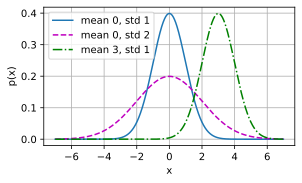

In [7]:
# Evaluate normal() over a grid of x, for a few (mu, sigma) pairs -- NumPy is fine
# here since this is a static plot, not a gradient computation
x = np.arange(-7, 7, 0.01)                            # plotting grid
params = [(0, 1), (0, 2), (3, 1)]                     # (mean, std) pairs to compare
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
    ylabel='p(x)', figsize=(4.5, 2.5),
    legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

Changing $\mu$ shifts the curve along the $x$-axis; increasing $\sigma$ spreads it
out and lowers its peak.

Now suppose observations are the true linear signal plus additive Gaussian noise,
$y = \mathbf{w}^\top\mathbf{x} + b + \epsilon$ with $\epsilon \sim \mathcal{N}(0,
\sigma^2)$. Then $y$ given $\mathbf{x}$ is itself normally distributed around the
prediction:

$$P(y \mid \mathbf{x}) = \frac{1}{\sqrt{2\pi\sigma^2}}\exp\left(-\frac{1}{2\sigma^2}\left(y - \mathbf{w}^\top\mathbf{x} - b\right)^2\right).$$

Under the **maximum likelihood** principle, the best parameters make the observed
data most probable. Since examples are drawn independently, the dataset's likelihood
factorizes as $P(\mathbf{y}\mid\mathbf{X}) = \prod_{i=1}^n p(y^{(i)} \mid
\mathbf{x}^{(i)})$; maximizing a product of exponentials is awkward, so instead we
minimize the **negative log-likelihood**,

$$-\log P(\mathbf{y} \mid \mathbf{X}) = \sum_{i=1}^n \frac{1}{2}\log(2\pi\sigma^2) + \frac{1}{2\sigma^2}\left(y^{(i)} - \mathbf{w}^\top\mathbf{x}^{(i)} - b\right)^2.$$

Holding $\sigma$ fixed, the first term does not depend on $(\mathbf{w}, b)$, and the
second is exactly the sum of squared errors up to the constant factor
$\frac{1}{\sigma^2}$ — which does not change where the minimum is. So minimizing mean
squared error is precisely maximum-likelihood estimation under an assumption of
additive Gaussian noise, not an arbitrary design choice.

**A worked special case (the book's first exercise for this section).** Drop the
features entirely: given $x_1, \ldots, x_n \in \mathbb{R}$, what constant $b$
minimizes $\sum_i (x_i - b)^2$? Differentiating and setting to zero gives
$b^* = \frac{1}{n}\sum_i x_i$ — the **sample mean**. That is no coincidence: by the
same maximum-likelihood argument above, the sample mean is exactly the MLE for $\mu$
when the $x_i$ are $\mu$ plus Gaussian noise. The cell below checks the closed form
against a small numerical search around it.

In [8]:
# The zero-feature special case: b* = mean(x) minimizes sum (x_i - b)^2 -- and
# doubles as the Gaussian MLE for mu (book Sec. 3.1.6, Exercise 1)
torch.manual_seed(1)
xs = torch.randn(200) * 2 + 5                        # 200 samples from N(5, 2^2)
b_star = xs.mean()                                    # closed-form optimum
candidates = b_star + torch.linspace(-1, 1, 21)       # perturb b* in both directions
losses = torch.tensor([((xs - b) ** 2).sum() for b in candidates])
print('b*  = mean(x)        :', b_star.item())
print('loss at b*           :', ((xs - b_star) ** 2).sum().item())
print('grid minimum at b =  :', candidates[losses.argmin()].item(), '(matches b* up to grid spacing)')

b*  = mean(x)        : 4.950663089752197
loss at b*           : 847.2830810546875
grid minimum at b =  : 4.950663089752197 (matches b* up to grid spacing)


## 3.1.4 Linear Regression as a Neural Network

Linear models are too simple to express the complex architectures this book
eventually builds, but neural networks are general enough to **subsume** linear
regression as a special case: a network where every feature is an input neuron, all
connected directly to the single output.

The inputs are $x_1, \ldots, x_d$ ($d$ is the **number of inputs**, or the feature
dimensionality); the single output neuron is $o_1 = \hat{y}$. Input values are given,
not computed, so the input layer does not count — there is exactly one *computed*
neuron. Linear regression is therefore a **single-layer, fully connected** neural
network; later chapters stack many more.

### 3.1.4.1 Biology

Linear regression predates computational neuroscience, but the neuron analogy is
where cyberneticists Warren McCulloch and Walter Pitts started when building early
models of artificial neurons. A biological neuron's **dendrites** receive input
signals $x_i$, weighted by **synaptic weights** $w_i$ (activating or inhibiting via
$x_i w_i$); the **nucleus** aggregates them into $y = \sum_i x_i w_i + b$, possibly
followed by a nonlinearity $\sigma(y)$; the **axon** then carries the result onward
through **synapses** to the next neuron.

The analogy is evocative rather than mechanistic — much as studying birds inspired
but did not drive the engineering of airplanes, today's deep learning draws at least
as much from mathematics, statistics, linguistics, and computer science as from
neuroscience.

## 3.1.5 Summary

- **Terminology**: a training set of **examples**, each with **features** and a
  **label**; we fit **parameters** $(\mathbf{w}, b)$ and tune **hyperparameters**
  like $\eta$ and $|\mathcal{B}|$.
- **Model**: $\hat{y} = \mathbf{w}^\top\mathbf{x} + b$, an affine transformation;
  batched as $\hat{\mathbf{y}} = \mathbf{X}\mathbf{w} + b$ via the design matrix
  $\mathbf{X}$.
- **Loss**: mean squared error $L(\mathbf{w}, b) = \frac{1}{n}\sum_i \frac{1}{2}
  (\hat{y}^{(i)} - y^{(i)})^2$; training minimizes it.
- **Analytic solution**: $\mathbf{w}^* = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$
  — a rare closed form, unique when $\mathbf{X}$ has full column rank; verified above
  on noiseless synthetic data.
- **Minibatch SGD** is the general-purpose fallback that scales to models with no
  closed form — sample a random batch, average its gradient, step against it; what we
  ultimately care about is **generalization**, not an exact fit to the training
  minimizer.
- **Vectorization** turns $n$ Python-level operations into one call into compiled,
  parallel code — the timing demo above shows the difference is not subtle.
- **Gaussian connection**: minimizing squared error is *exactly* maximum-likelihood
  estimation under additive $\mathcal{N}(0,\sigma^2)$ noise; the zero-feature special
  case ($b^* = $ sample mean) makes the connection concrete.
- Linear regression is architecturally the simplest possible neural network: a
  **single-layer, fully connected** network with one computed (output) neuron — the
  foundation the rest of this book builds on.